<a href="https://colab.research.google.com/github/guilhermemoraes-lasalle/ColecoesEassociacoes/blob/main/Exercicio_Pratico_Analise_Visual_Vendas_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático — Análise Visual de Vendas com Pandas e Matplotlib

**Objetivo:** Ler e manipular um conjunto de dados fictício de vendas utilizando Pandas e criar visualizações com Matplotlib para responder a perguntas de negócio.

O notebook está dividido em:
1. Preparação do ambiente e criação dos dados.
2. Faturamento por produto.
3. Evolução das vendas ao longo do tempo.
4. Distribuição da quantidade vendida por produto.


## Bloco 1 — Preparação do Ambiente e Dados


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Criação de um dataset fictício de vendas
np.random.seed(42)

datas = pd.date_range(
    start="2024-01-01",
    end="2024-06-30",
    freq="D"
)

produtos = [
    "Notebook",
    "Smartphone",
    "Fone de Ouvido",
    "Monitor"
]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(
        produtos,
        size=300,
        p=[0.2, 0.4, 0.25, 0.15]
    ),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

# Atribuindo preços de acordo com o produto
precos = {
    "Notebook": 3500,
    "Smartphone": 2000,
    "Fone de Ouvido": 150,
    "Monitor": 1200
}

df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
df.head()


Dataset criado com sucesso! Primeiras linhas:


,Data,Produto,Quantidade,Preco_Unitario
0,2024-04-12,Monitor,3,1200
1,2024-06-28,Smartphone,1,2000
2,2024-04-02,Monitor,5,1200
3,2024-01-15,Fone de Ouvido,4,150
4,2024-04-16,Fone de Ouvido,1,150


## Tarefa 1 — Faturamento por Produto


In [2]:
# Criando a coluna Faturamento_Total
df["Faturamento_Total"] = (
    df["Quantidade"] * df["Preco_Unitario"]
)

print("Coluna Faturamento_Total criada:")
df.head()


Coluna Faturamento_Total criada:


,Data,Produto,Quantidade,Preco_Unitario,Faturamento_Total
0,2024-04-12,Monitor,3,1200,3600
1,2024-06-28,Smartphone,1,2000,2000
2,2024-04-02,Monitor,5,1200,6000
3,2024-01-15,Fone de Ouvido,4,150,600
4,2024-04-16,Fone de Ouvido,1,150,150


In [3]:
# Agrupando por produto e somando o faturamento
faturamento_produto = (
    df.groupby("Produto")["Faturamento_Total"]
    .sum()
    .sort_values(ascending=False)
)

print("Faturamento total por produto:")
faturamento_produto


Faturamento total por produto:


,Faturamento_Total
Produto,
Notebook,686000
Smartphone,626000
Monitor,213600
Fone de Ouvido,30150


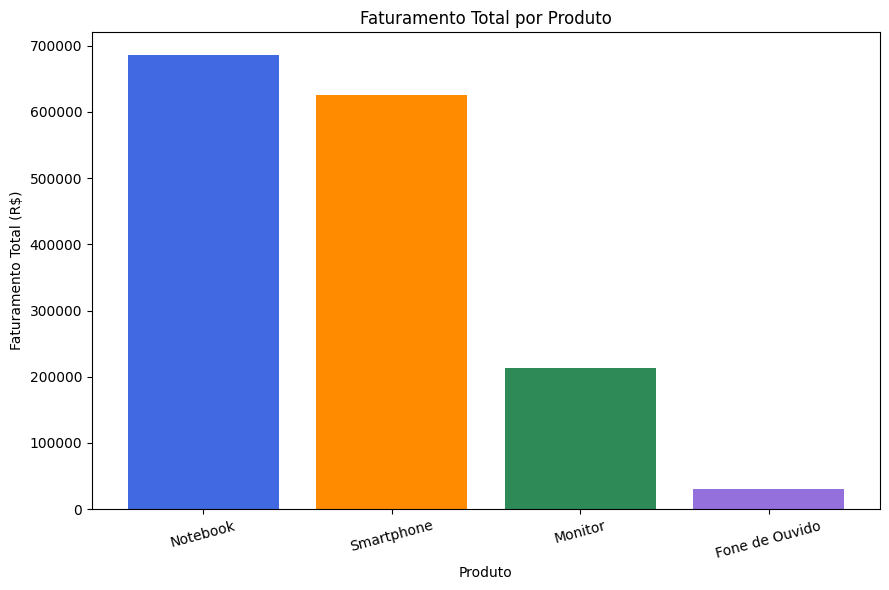

In [4]:
# Gráfico de barras do faturamento por produto
plt.figure(figsize=(9, 6))

plt.bar(
    faturamento_produto.index,
    faturamento_produto.values,
    color=["royalblue", "darkorange", "seagreen", "mediumpurple"]
)

plt.title("Faturamento Total por Produto")
plt.xlabel("Produto")
plt.ylabel("Faturamento Total (R$)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Análise — Tarefa 1

O gráfico permite comparar diretamente quanto cada categoria de produto contribuiu para o faturamento total da empresa durante o período analisado.


## Tarefa 2 — Evolução das Vendas ao Longo do Tempo


In [5]:
# Garantindo que a coluna Data esteja no formato datetime
df["Data"] = pd.to_datetime(df["Data"])

# Criando a coluna Mes
df["Mes"] = df["Data"].dt.to_period("M")

print("Coluna Mes criada:")
df[["Data", "Mes"]].head()


Coluna Mes criada:


,Data,Mes
0,2024-04-12,2024-04
1,2024-06-28,2024-06
2,2024-04-02,2024-04
3,2024-01-15,2024-01
4,2024-04-16,2024-04


In [6]:
# Calculando o faturamento total por mês
faturamento_mensal = (
    df.groupby("Mes")["Faturamento_Total"]
    .sum()
)

print("Faturamento por mês:")
faturamento_mensal


Faturamento por mês:


,Faturamento_Total
Mes,
2024-01,210300
2024-02,235950
2024-03,278450
2024-04,247650
2024-05,379650
2024-06,203750


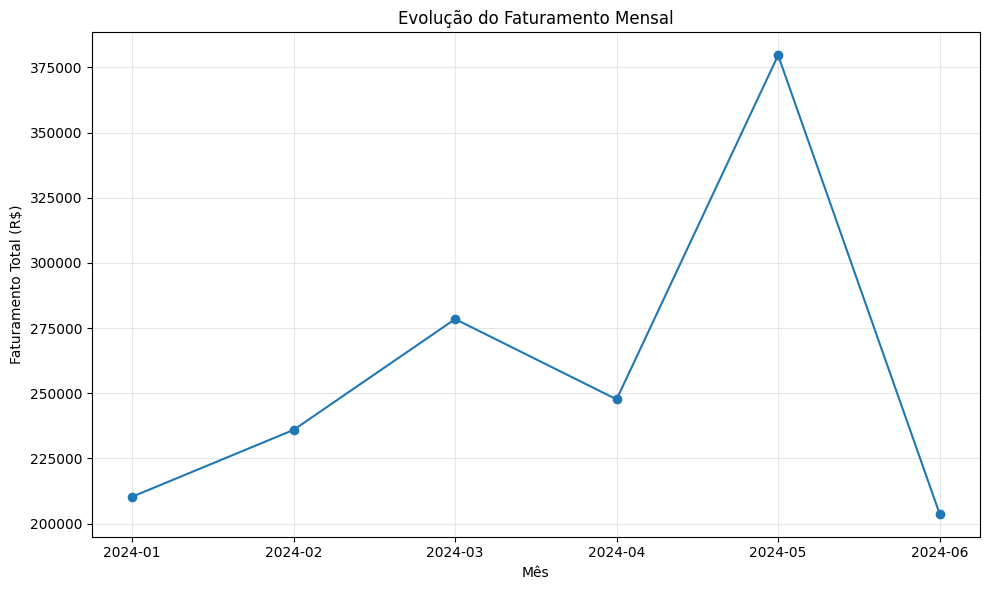

In [7]:
# Convertendo os períodos para texto para facilitar a visualização
meses = faturamento_mensal.index.astype(str)

plt.figure(figsize=(10, 6))

plt.plot(
    meses,
    faturamento_mensal.values,
    marker="o"
)

plt.title("Evolução do Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento Total (R$)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Análise — Tarefa 2

O gráfico de linha apresenta a evolução do faturamento entre janeiro e junho de 2024, facilitando a identificação de meses com crescimento ou redução nas vendas.


## Tarefa 3 — Distribuição da Quantidade Vendida


In [8]:
# Somando a quantidade de itens vendidos por produto
quantidade_produto = (
    df.groupby("Produto")["Quantidade"]
    .sum()
    .sort_values(ascending=False)
)

print("Quantidade total vendida por produto:")
quantidade_produto


Quantidade total vendida por produto:


,Quantidade
Produto,
Smartphone,313
Fone de Ouvido,201
Notebook,196
Monitor,178


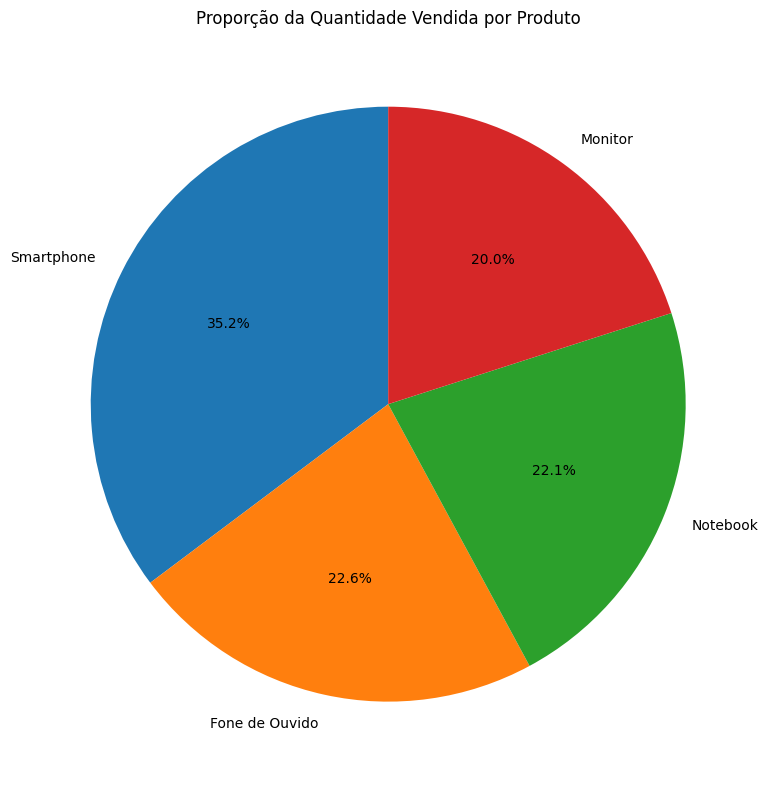

In [9]:
# Gráfico de pizza
plt.figure(figsize=(8, 8))

plt.pie(
    quantidade_produto.values,
    labels=quantidade_produto.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporção da Quantidade Vendida por Produto")
plt.tight_layout()
plt.show()


### Análise — Tarefa 3

O gráfico de pizza mostra a participação de cada produto na quantidade total de itens vendidos. As porcentagens permitem comparar de forma simples a proporção das vendas entre as categorias.


## Visualização Final do DataFrame


In [10]:
# Exibindo as primeiras linhas após todas as transformações
df.head(10)


,Data,Produto,Quantidade,Preco_Unitario,Faturamento_Total,Mes
0,2024-04-12,Monitor,3,1200,3600,2024-04
1,2024-06-28,Smartphone,1,2000,2000,2024-06
2,2024-04-02,Monitor,5,1200,6000,2024-04
3,2024-01-15,Fone de Ouvido,4,150,600,2024-01
4,2024-04-16,Fone de Ouvido,1,150,150,2024-04
5,2024-03-12,Smartphone,5,2000,10000,2024-03
6,2024-01-21,Smartphone,5,2000,10000,2024-01
7,2024-04-12,Smartphone,3,2000,6000,2024-04
8,2024-05-01,Notebook,5,3500,17500,2024-05
9,2024-03-15,Fone de Ouvido,5,150,750,2024-03


## Conclusão

A análise utilizou Pandas para criação, transformação e agrupamento dos dados e Matplotlib para construir três tipos de visualização:

- **Gráfico de barras:** faturamento por produto;
- **Gráfico de linha:** evolução mensal do faturamento;
- **Gráfico de pizza:** proporção da quantidade vendida por produto.

Essas visualizações permitem analisar o desempenho dos produtos tanto em termos financeiros quanto em volume de vendas.
